# Highlights — what "Germanic" vs "Latinate" actually mean

- English is two vocabularies blended into one: an old **Germanic** core (everyday words like *eat, drink, child, home, water, need*) inherited from Old English, and a younger **Latinate** layer (formal-sounding words like *consume, beverage, infant, residence, aqueous, require*) borrowed from Latin and French mostly after the Norman invasion of 1066.
- Same meanings, different *feel*. *child / infant*, *ask / request*, *begin / commence*, *help / assist* — the Germanic word usually feels everyday; the Latinate one usually feels formal. That's the whole reason this axis is a register proxy.
- To label a word, you trace its **family tree** backwards through a big etymology database (Etymological WordNet, ~6M word-origin links scraped from Wiktionary). If the chain ends at Old English / Old Norse / Dutch → Germanic. If it ends at Latin / Old French → Latinate. Only content words count (nouns, verbs, adjectives, adverbs); *the*, *a*, *of* are skipped because they'd swamp the signal.
- The **ratio** we report is `Latinate / (Latinate + Germanic)`. 0 means pure Germanic; 1 means pure Latinate. About 0.34 is typical spoken English, about 0.50 is typical written English — those reference values come from Bar-Ilan & Berman (next cell).


# Highlights — Bar-Ilan & Berman (2007), the paper our metric comes from
- they showed that the Germanic/Latinate vocabulary split is a real, measurable axis of register — spoken  English sits lower on it, written English sits higher, and the gap is stable enough to be cited as a reference.
- Young children produce spoken and written text at similar Latinate proportions they haven't yet learned to "switch vocabularies" by medium. As they grow and get more schooling, the gap opens up: their written register climbs toward the Latinate side while their spoken stays closer to Germanic.
- The two reference numbers everyone cites — **spoken ≈ 0.34** and **written ≈ 0.50** — come from this paper. They are the horizontal dashed lines on the chart in section 4 below.
- The gap was tested across **two text types** (storytelling and explaining) and held in both, so the spoken/written difference is a real property of the medium, not a quirk of one genre.
- **All of their measurements were done by hand** — real humans looking up each word in etymology dictionaries. They never validated any automated tool. This means we can cite them for *the metric is meaningful*, but not for *our specific tool is accurate* — that's a separate question we address with EtymoLink in the next phase.


# 01 — BabyLM 2026 Strict-Small: Corpus Baseline

**Question:** what is in the BabyLM 2026 Strict-Small corpus, and where does it sit on the Germanic/Latinate register axis before we manipulate anything?

**Why this notebook exists:** before we shift the corpus toward Germanic vocabulary, we need (a) a clear picture of the baseline composition per source, and (b) a single citable number per source on the Latinate/Germanic ratio. The headline artifact is the chart in section 4: per-source register score with the Bar-Ilan & Berman (2007) reference lines drawn on top (0.34 spoken / 0.50 written). That tells Lukas the metric works and shows the headroom we have to manipulate.

**Method backbone:** see `literature/etymological-register/briefs/00-measurement-methods-v2.md` for the chosen measurement stack (Macro-Etym primary, suffix regex corroborator, EtymoLink calibration).

**Scope (today):** sections 1–3 are must-finish; 4–6 are stretch goals per the time ladder.

## 1. Setup

Imports, paths, and version-pin print so the notebook is reproducible from a single re-execution.

In [ ]:
import sys
import re
import subprocess
import io
from pathlib import Path
from collections import Counter

import requests
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import datasets

print("Python", sys.version.split()[0])
print("pandas", pd.__version__)
print("spacy", spacy.__version__)
print("datasets", datasets.__version__)

# Notebook lives in notebooks/; data lives one level up. Resolve absolute path
# so subprocess calls into macroetym (which has its own cwd) still find files.
DATA_DIR = (Path.cwd() / ".." / "data" / "babylm_2026" / "strict_small").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)


# Fixed display order: spoken/dialogue first, then written. Matches the
# Bar-Ilan & Berman spoken-vs-written axis the chart in section 4 sits on.
SOURCE_ORDER = [
    "switchboard",
    "bnc_spoken",
    "childes",
    "open_subtitles",
    "simple_wiki",
    "gutenberg",
]

NLP = spacy.load("en_core_web_sm", disable=["parser", "ner"])
NLP.max_length = 50_000_000


Python 3.13.12
pandas 3.0.3
spacy 3.8.14
datasets 4.8.5


## 2. Load corpus

Pull the BabyLM 2026 Strict-Small bundle into `data/babylm_2026/strict_small/` (gitignored per repo `.gitignore`). Confirm the source-file inventory matches the official release and print raw byte sizes as a sanity check.

If the 2026 corpus has not dropped yet, fall back to the BabyLM 2024 Strict-Small (same 10M-word shape) and flag the substitution in this section.

In [2]:
from huggingface_hub import hf_hub_download

REPO_ID = "BabyLM-community/BabyLM-2026-Strict-Small"
SOURCE_FILES = {s: f"{s}.train.txt" for s in SOURCE_ORDER}

# Sanity targets from the official 2026 Strict-Small release card.
SANITY_TARGETS = {
    "childes": 2_840_000,
    "gutenberg": 2_560_000,
    "open_subtitles": 2_280_000,
    "simple_wiki": 1_530_000,
    "bnc_spoken": 762_000,
    "switchboard": 24_800,
}

# Pull each source file from the Hub and mirror it into DATA_DIR. We do not
# use load_dataset() because it concatenates into one column and loses the
# per-source split we need downstream.
source_paths = {}
for source, fname in SOURCE_FILES.items():
    cached = hf_hub_download(REPO_ID, fname, repo_type="dataset")
    local = DATA_DIR / fname
    local.write_bytes(Path(cached).read_bytes())
    source_paths[source] = local

print(f"Mirrored to {DATA_DIR}")
print()
print(f"{'source':<16} {'bytes':>12} {'tokens':>12} {'target':>12} {'delta%':>8}")
print("-" * 64)
violations = []
for source in SOURCE_ORDER:
    p = source_paths[source]
    text = p.read_text(encoding="utf-8")
    tokens = len(text.split())
    target = SANITY_TARGETS[source]
    delta = 100 * (tokens - target) / target
    print(f"{source:<16} {p.stat().st_size:>12,} {tokens:>12,} {target:>12,} {delta:>+7.2f}%")
    if abs(delta) > 2:
        violations.append({"source": source, "tokens": tokens, "target": target, "delta_pct": delta})
assert not violations, f"Corpus sanity check failed (|delta| > 2%): {violations}"


Mirrored to /Users/deep/Uni/ss2026/llm-practical-course/projects/babylm/git/babylm-2026/data/babylm_2026/strict_small

source                  bytes       tokens       target   delta%
----------------------------------------------------------------
switchboard           122,528       24,791       24,800   -0.04%
bnc_spoken          4,064,608      762,073      762,000   +0.01%
childes            15,159,891    2,841,101    2,840,000   +0.04%
open_subtitles     12,159,704    2,282,877    2,280,000   +0.13%


simple_wiki         8,861,946    1,531,437    1,530,000   +0.09%
gutenberg          14,031,163    2,557,721    2,560,000   -0.09%


## 3. Composition table

Per source: file count, token count (whitespace-split, fast), sentence count, mean sentence length, type/token ratio. One pandas DataFrame, one bar chart of token counts. This is the mandatory "we know our data" baseline.

# Highlights — the six sources, what they are, and roughly when they were made

- BabyLM bundles six independent sources picked to span the spoken-to-written gradient a child actually encounters by age 6. The chart in section 4 below picks that gradient up: the pure-spoken sources cluster at the low-Latinate end and the purely-written sources cluster at the high end.
- The **time period** column below is a rough estimate of when each source's material was produced. Worth being aware of: historical English uses more Latinate vocabulary even in everyday contexts, so a Victorian children's book reads more formal than a modern one would. Some of Macro-Etym's Latinate skew on Gutenberg is likely a *period* effect, not a *genre* effect.

| Source | What it is | Where it sits on the axis | When it was made (rough) |
|---|---|---|---|
| **CHILDES** | transcribed child-directed speech (adults talking to young kids) | pure spoken, simplest | ~1970s–2010s |
| **Switchboard** | transcribed American telephone conversations between strangers | pure spoken, adult | 1990–1991 |
| **BNC spoken** | transcribed adult dialogue from natural British settings | pure spoken, adult | 1991–1994 |
| **OpenSubtitles** | text from movie and TV subtitle files | in-between — scripted speech written to sound conversational | mostly ~1990s–today |
| **Gutenberg children's** | public-domain children's literature (*Alice in Wonderland*, *Peter Pan*, etc.) | written, for kids | mostly 1860s–1920s (public-domain era) |
| **Simple English Wikipedia** | articles from `simple.wikipedia.org`, deliberately simple vocabulary | written, deliberately simple | ~2003–today |


                files   tokens  sentences  mean_sent_len     ttr  pct_of_total
source                                                                        
switchboard         1    24791       2892         8.5723  0.1271        0.2479
bnc_spoken          1   762073      65220        11.6847  0.0477        7.6207
childes             1  2841101     531305         5.3474  0.0204       28.4110
open_subtitles      1  2282877     386046         5.9135  0.0492       22.8288
simple_wiki         1  1531437      58709        26.0852  0.0847       15.3144
gutenberg           1  2557721      59934        42.6756  0.0486       25.5772


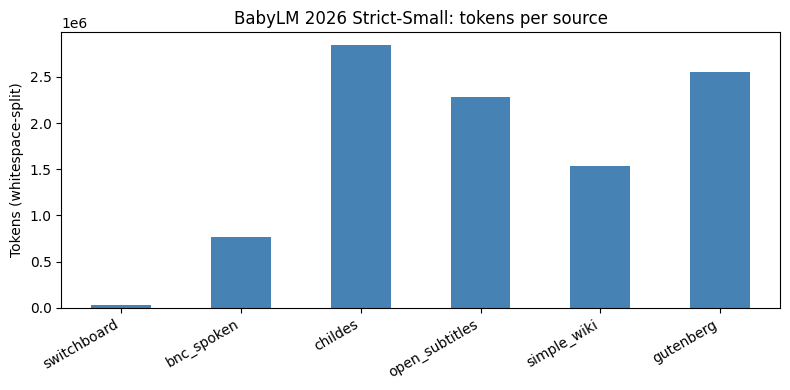

In [3]:
rows = []
for source in SOURCE_ORDER:
    text = source_paths[source].read_text(encoding="utf-8")
    lines = [ln for ln in text.splitlines() if ln.strip()]
    tokens = text.split()
    types = set(t.lower() for t in tokens)
    rows.append({
        "source": source,
        "files": 1,
        "tokens": len(tokens),
        "sentences": len(lines),
        "mean_sent_len": len(tokens) / max(len(lines), 1),
        "ttr": len(types) / max(len(tokens), 1),
    })

composition = pd.DataFrame(rows).set_index("source").loc[SOURCE_ORDER]
composition["pct_of_total"] = 100 * composition["tokens"] / composition["tokens"].sum()
print(composition.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
composition["tokens"].plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("Tokens (whitespace-split)")
ax.set_title("BabyLM 2026 Strict-Small: tokens per source")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Register score per source (headline chart)

Run Macro-Etym per source file, report the Latinate/Germanic open-class ratio. Bar chart per source with horizontal dashed reference lines at 0.34 (Bar-Ilan & Berman spoken) and 0.50 (written).

# Highlights — what **Macro-Etym** is and what it doesn't see

- **What it is.** A command-line tool that takes a text file and returns the percentage of words from each etymological origin family (Germanic, Latinate, Hellenic, etc.) for the content words it recognises. Under the hood it looks every word up in **Etymological WordNet** (a ~6 million-link database of word origins scraped from Wiktionary) and walks the family tree back to a root language.
- **How we use it.** Once per source file (`macroetym childes.train.txt` etc.), parse the percentages it prints, compute `Latinate / (Latinate + Germanic)`. That single number per source is what becomes the chart below.
- **Shortcoming — the ~30% blind spot.** It doesn't recognise about 30% of English words (proper nouns, rare or technical words, slang, some derivations). Those are silently dropped from *both* halves of the ratio. That's why our absolute numbers can drift above Bar-Ilan & Berman's references — the words it *does* know are skewed toward the Latinate side. The *ordering* between sources is still trustworthy.
- **Shortcoming — never independently benchmarked.** Bar-Ilan & Berman hand-counted; they didn't validate any automated tool. So Macro-Etym inherits the *construct* (the ratio is meaningful) but needs the *pipeline* checked separately. That's EtymoLink's job — see section 6.


switchboard      Latinate=56.95  Germanic=41.09  ratio=0.581


bnc_spoken       Latinate=65.55  Germanic=31.18  ratio=0.678


childes          Latinate=55.87  Germanic=40.36  ratio=0.581


open_subtitles   Latinate=64.88  Germanic=30.56  ratio=0.680


simple_wiki      Latinate=66.02  Germanic=27.74  ratio=0.704


gutenberg        Latinate=63.61  Germanic=33.70  ratio=0.654


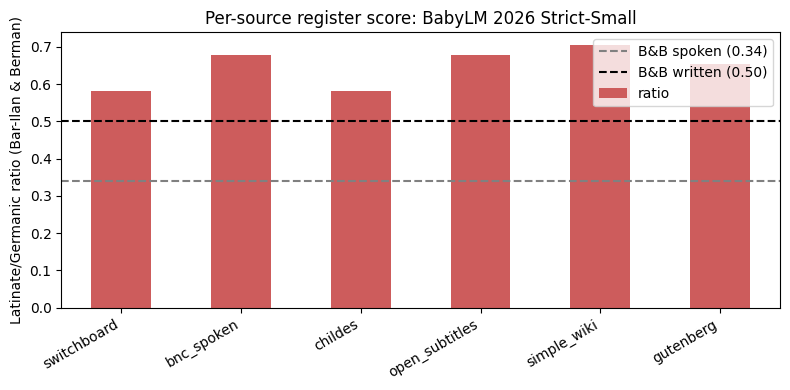

In [4]:
# Macro-Etym CLI returns a percentage-per-language-family table to stdout.
# We parse it and compute Bar-Ilan & Berman's ratio as Latinate / (Latinate + Germanic).
# Reference values 0.34 (spoken) / 0.50 (written) drawn as dashed lines below.

def macroetym_ratio(path: Path) -> tuple[float, float, float]:
    out = subprocess.run(
        ["macroetym", str(path)],
        capture_output=True, text=True, check=True,
    ).stdout
    family = {}
    for line in out.splitlines():
        parts = line.split()
        if len(parts) >= 2:
            try:
                family[parts[0]] = float(parts[-1])
            except ValueError:
                continue
    lat = family.get("Latinate", 0.0)
    ger = family.get("Germanic", 0.0)
    return lat, ger, lat / (lat + ger) if (lat + ger) > 0 else float("nan")

register = []
for source in SOURCE_ORDER:
    lat, ger, ratio = macroetym_ratio(source_paths[source])
    register.append({"source": source, "latinate_pct": lat, "germanic_pct": ger, "ratio": ratio})
    print(f"{source:<16} Latinate={lat:>5.2f}  Germanic={ger:>5.2f}  ratio={ratio:.3f}")

register_df = pd.DataFrame(register).set_index("source").loc[SOURCE_ORDER]

fig, ax = plt.subplots(figsize=(8, 4))
register_df["ratio"].plot.bar(ax=ax, color="indianred")
ax.axhline(0.34, linestyle="--", color="gray", label="B&B spoken (0.34)")
ax.axhline(0.50, linestyle="--", color="black", label="B&B written (0.50)")
ax.set_ylabel("Latinate/Germanic ratio (Bar-Ilan & Berman)")
ax.set_title("Per-source register score: BabyLM 2026 Strict-Small")
ax.set_xlabel("")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Validity caveat (denominator mismatch).** macro-etym excludes ~30% unrecognised tokens (OOV). The reported ratio is Latinate / (Latinate + Germanic) over *recognised open-class words only*, not all words. Bar-Ilan & Berman's reference values (0.34 spoken / 0.50 written) are hand-counted from full narratives, so the chart compares against a different denominator. The EtymoLink precision/recall calibration in the next phase addresses this; section 6 below is only a coverage teaser.

## 5. Qualitative extremes

Top 10 most-Latinate and top 10 most-Germanic sentences, side by side. Cheap, memorable, sells the metric in a way a single ratio cannot.

**Method note.** Section 5 uses **suffix-regex** (a corroborating proxy, not macro-etym) to score individual sentences, because macro-etym's subprocess-per-file model is infeasible at sentence scale. These rankings are qualitative — they show morphological extremes, not the absolute ratios charted in section 4.

In [5]:
# Macro-etym requires a subprocess per file — running it on every sentence is
# infeasible. For sentence-level ranking we use the same suffix-regex proxy
# documented as the fallback in section 4, scored on spaCy lemmas. The ranking
# is qualitative (which sentences read most Latinate / most Germanic), not a
# claim about the absolute ratio.

LATINATE_SUFFIX = re.compile(r"(tion|ity|ment|ance|ence|ate|ic|ous|ive)$")
GERMANIC_SUFFIX = re.compile(r"(ness|dom|hood|ship|ly|ful)$")

def suffix_ratio(text: str) -> tuple[float, int]:
    doc = NLP(text)
    lat = ger = 0
    for tok in doc:
        if tok.pos_ not in {"NOUN", "VERB", "ADJ", "ADV"}:
            continue
        lemma = tok.lemma_.lower()
        if LATINATE_SUFFIX.search(lemma):
            lat += 1
        elif GERMANIC_SUFFIX.search(lemma):
            ger += 1
    matched = lat + ger
    return (lat / matched if matched else float("nan")), matched

# Sample a fixed number of sentences per source so one big source doesn't
# dominate the extremes list. Deterministic slice for reproducibility.
SAMPLE_PER_SOURCE = 2000

scored = []
for source in SOURCE_ORDER:
    lines = [ln.strip() for ln in source_paths[source].read_text(encoding="utf-8").splitlines() if ln.strip()]
    step = max(1, len(lines) // SAMPLE_PER_SOURCE)
    for ln in lines[::step][:SAMPLE_PER_SOURCE]:
        if 4 <= len(ln.split()) <= 40:
            ratio, matched = suffix_ratio(ln)
            if matched >= 3:
                scored.append({"source": source, "ratio": ratio, "sentence": ln})

scored_df = pd.DataFrame(scored)
print(f"Scored {len(scored_df)} sentences across {len(SOURCE_ORDER)} sources.")
print()
print("=== Top 10 most-Latinate (suffix proxy) ===")
for _, r in scored_df.nlargest(10, "ratio").iterrows():
    print(f"[{r['source']:<14} {r['ratio']:.2f}] {r['sentence']}")
print()
print("=== Top 10 most-Germanic (suffix proxy) ===")
for _, r in scored_df.nsmallest(10, "ratio").iterrows():
    print(f"[{r['source']:<14} {r['ratio']:.2f}] {r['sentence']}")


Scored 188 sentences across 6 sources.

=== Top 10 most-Latinate (suffix proxy) ===
[switchboard    1.00] B:	or I, I just since that they didn't have a commitment to the stability of the organizations they were, were making the decisions for.
[switchboard    1.00] A:	And you know, when, um, when last year the elections were going, on the governors election and state and, you know.
[switchboard    1.00] B:	that, but that's a, that's an impossibility, I think given the differences in the world,
[switchboard    1.00] B:	and I was paying unbelievable rates for both car insurance and for home insurance. Um,
[bnc_spoken     1.00] I want to give you some positive feedback, you asked for it, from the National Alliance of Women's Organisations, er, which represents two hundred and six organisations, in, all in all about five million women.
[bnc_spoken     1.00] There have also been several representations from those sitting on my left hand side, about the possible answers to question one D in t

## 6. EtymoLink coverage probe

Fraction of the corpus's top-1k lemmas that appear in EtymoLink (Gao & Sun 2024, 5,361 curated entries). One number. This is the teaser for next week's full precision/recall calibration step — it shows we have scoped the pipeline-validity question, not that we have answered it.

# Highlights — what **EtymoLink** is and what it can't do

- **What it is.** A small but high-quality dataset of **5,313 English words** with their etymological origin labeled **by hand** (Gao & Sun, ACL workshop LChange 2024, CC BY 4.0 licensed). 
- **How we use it today.** Just a **coverage probe** — how many of our corpus's top-1,000 most-frequent content words appear in EtymoLink. The result (44, or 4.4%) tells us how big the calibration slice will be in the next phase. Today's notebook does **not** yet measure Macro-Etym's accuracy against EtymoLink — that's the next step.
- **How we'll use it next phase.** Take the words that *are* in EtymoLink, run Macro-Etym on the same words, compare. That gives us a **precision/recall** number — the proper answer to *how accurate is your tool, really?* Without this, our citation of Bar-Ilan & Berman doesn't survive a careful read.
- **Shortcoming — tiny by design.** Only ~5k words, vs the ~50k+ unique words in a corpus like BabyLM. EtymoLink can't be a primary corpus scorer; it's a *precision instrument*, not a *coverage instrument*. The 4.4% number is small by design, not because anything is broken.
- **Shortcoming — frequency mismatch.** It targets rare, etymologically interesting words. Corpora are dominated by common Germanic core words (*be, have, go, child, water*). So coverage of high-frequency lemmas looks low even on a perfectly-built tool — that's why the 4.4% needs an explanation, not an apology.


In [6]:
ETYMOLINK_URL = "https://raw.githubusercontent.com/yuan-w-gao/etymolink/main/annotated_formatted.csv"

resp = requests.get(ETYMOLINK_URL, timeout=30)
resp.raise_for_status()
etymolink = pd.read_csv(io.StringIO(resp.text))
etymolink_words = set(w.lower() for w in etymolink["word"].dropna() if isinstance(w, str))
print(f"EtymoLink: {len(etymolink_words):,} unique surface forms")

# Top-1k corpus lemmas, open-class only, computed from a token sample per
# source so spaCy stays fast and one big source does not dominate the ranking.
SAMPLE_TOKENS_PER_SOURCE = 50_000

lemma_counts: Counter[str] = Counter()
for source in SOURCE_ORDER:
    text = source_paths[source].read_text(encoding="utf-8")
    sample = " ".join(text.split()[:SAMPLE_TOKENS_PER_SOURCE])
    doc = NLP(sample)
    for tok in doc:
        if tok.is_alpha and tok.pos_ in {"NOUN", "VERB", "ADJ", "ADV"}:
            lemma_counts[tok.lemma_.lower()] += 1

top1k = [w for w, _ in lemma_counts.most_common(1000)]
covered = sum(1 for w in top1k if w in etymolink_words)
print(f"Top-1k corpus lemmas covered by EtymoLink: {covered}/1000 = {covered/10:.1f}%")
print()
print("Note: low coverage on high-frequency lemmas is expected — the top-1k is")
print("dominated by Germanic core vocabulary, while EtymoLink's 5.3k entries are")
print("curated for etymological precision rather than frequency coverage. The full")
print("precision/recall calibration in the next phase probes a different slice.")


EtymoLink: 5,313 unique surface forms


Top-1k corpus lemmas covered by EtymoLink: 44/1000 = 4.4%

Note: low coverage on high-frequency lemmas is expected — the top-1k is
dominated by Germanic core vocabulary, while EtymoLink's 5.3k entries are
curated for etymological precision rather than frequency coverage. The full
precision/recall calibration in the next phase probes a different slice.


# Open questions / next steps
### Calibration leads

- **Check whether Bar-Ilan & Berman's 2007 narrative data is publicly available.** If we could obtain the exact texts they hand-counted, running Macro-Etym on those texts would give a **direct per-text calibration** — apples-to-apples with how they measured (Macro-Etym output and B&B output are the same thing: a Latinate proportion per text). This would be a *second* calibration arm alongside the EtymoLink precision/recall step planned for the next phase, hitting the construct from a different angle.
  - **First place to look:** CHILDES TalkBank at `childes.talkbank.org` — search for "Berman". Ruth Berman has donated a lot of narrative data there over the years; the English 2007 narratives may be among it.
  - **If not there:** email Ruth Berman directly. Short, polite request explaining the project and the use case. Linguistics data-sharing norms are generally cooperative for replication purposes.
  - **Even a negative outcome is worth recording** — "we asked and the data is not obtainable" is one sentence in the methods section that shows we tried the strongest calibration before settling for the next-best.
- Run against EtymoLink

### Per-frequency-band ratio. 
- This is THE central confound check. Split the vocabulary into frequency tiers (top 1k, 1k-5k, 5k-25k, rare). Compute Germanic/Latinate ratio within each band. If high-frequency words are heavily Germanic but the gap disappears for rare words, then "Germanic" is largely a proxy for "common" — and the whole register effect collapses into a frequency effect. This is exactly the question the pretraining plan flags as the biggest methodological risk. Cheap to compute (one notebook cell). If the gap survives the frequency split, the project is well-defended.

### Word length vs etymology. 
- Plot mean word length against the etymology label. Latinate words are typically longer; if our "Latinate score" correlates near-perfectly with mean word length, we're measuring length in disguise. If there's residual variance, etymology adds something.

### Per-POS breakdown. 
- Split the ratio by part of speech: nouns vs verbs vs adjectives vs adverbs. English is unusual here verbs are mostly Germanic (be, have, go, take, make, eat), nouns and adjectives are mostly where the Latinate borrowing lives (commence, residence, magnificent). A per-POS chart probably shows the register effect lives almost entirely in NOUN+ADJ space, which is itself a finding and tightens what "register manipulation" actually means in practice.

### The natural experiment already in the data
- Simple Wiki vs Regular Wiki on the same topics. We already have Simple Wikipedia. Download a small sample of Regular Wikipedia for matching article titles. Direct measure of "what does simplification do to register." This is a parallel corpus with everything else controlled — same topic, same facts, just different phrasing. The cleanest single comparison anywhere in this analysis.

### Readability metrics ensemble (Flesch-Kincaid, Gunning Fog, Coleman-Liau).
- Well-established, decades-old, anyone can interpret them. Compute per source, see how they correlate with our Latinate score. If our metric tracks Flesch-Kincaid almost perfectly, we're measuring readability under a fancier name. If there's residual variance, etymology adds a signal these metrics miss. Either way the comparison is a free citation magnet.

### Look into how the tool (Macro-Etym) operates